<a href="https://colab.research.google.com/github/CPTR295/NLP-Using-Transformers/blob/main/Text_Classification_Using_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from datasets import load_dataset, ClassLabel

In [2]:
emotions = load_dataset("dair-ai/emotion","split")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
emotions = emotions.cast_column("label",ClassLabel(num_classes=6,names=["sadness", "joy", "love", "anger", "fear", "surprise"]))

Casting the dataset:   0%|          | 0/16000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [6]:
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [7]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [8]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [9]:
def label_int2str(row):
  return emotions['train'].features['label'].int2str(row)
df['label_name']=df['label'].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


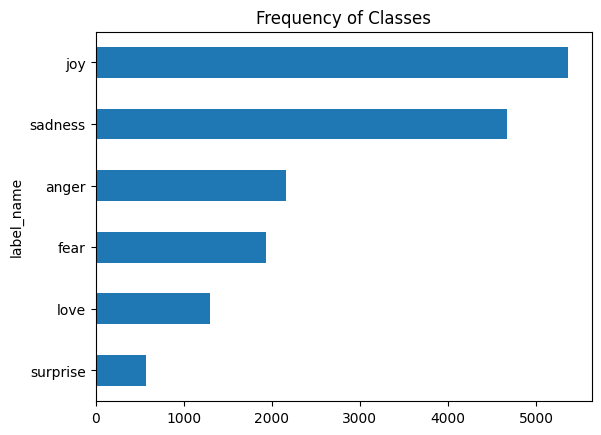

In [10]:
import matplotlib.pyplot as plt
df['label_name'].value_counts(ascending=True).plot.barh()
plt.title('Frequency of Classes')
plt.show()

In [11]:
from transformers import AutoTokenizer
#Auto Class - whose job is to automatically retrieve the model's configuration, pretrained weights, or vocabulary from the name of the checkpoint
model_ckpt = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [12]:
sample_text = 'Hello World!'
encoded_text = tokenizer(sample_text)
print(encoded_text)

{'input_ids': [101, 7592, 2088, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}


In [13]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'hello', 'world', '!', '[SEP]']


In [14]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] hello world! [SEP]


In [15]:
tokenizer.vocab_size

30522

In [16]:
tokenizer.model_max_length

512

In [17]:
tokenizer.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

In [18]:
emotions.reset_format()

In [19]:
def tokenize(batch):
  return tokenizer(batch['text'],padding=True,truncation=True)

In [20]:
print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [21]:
#Tokenize the dataset
emotions_encoded = emotions.map(tokenize,batched=True,batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [22]:
print(emotions_encoded["train"].column_names)

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


Transformers as Feature Extractors

In [23]:
import torch
from transformers import AutoModel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
print(model)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [25]:
for name, param in model.named_parameters():
    print(name, param.shape)

embeddings.word_embeddings.weight torch.Size([30522, 768])
embeddings.position_embeddings.weight torch.Size([512, 768])
embeddings.LayerNorm.weight torch.Size([768])
embeddings.LayerNorm.bias torch.Size([768])
transformer.layer.0.attention.q_lin.weight torch.Size([768, 768])
transformer.layer.0.attention.q_lin.bias torch.Size([768])
transformer.layer.0.attention.k_lin.weight torch.Size([768, 768])
transformer.layer.0.attention.k_lin.bias torch.Size([768])
transformer.layer.0.attention.v_lin.weight torch.Size([768, 768])
transformer.layer.0.attention.v_lin.bias torch.Size([768])
transformer.layer.0.attention.out_lin.weight torch.Size([768, 768])
transformer.layer.0.attention.out_lin.bias torch.Size([768])
transformer.layer.0.sa_layer_norm.weight torch.Size([768])
transformer.layer.0.sa_layer_norm.bias torch.Size([768])
transformer.layer.0.ffn.lin1.weight torch.Size([3072, 768])
transformer.layer.0.ffn.lin1.bias torch.Size([3072])
transformer.layer.0.ffn.lin2.weight torch.Size([768, 3072

In [26]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


In [27]:

inputs = {k:v.to(device) for k,v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1620]]]), hidden_states=None, attentions=None)


In [28]:
outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

In [29]:
def extract_hidden_states(batch):
    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}
    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

In [30]:
emotions_encoded.set_format("torch",columns=['input_ids','attention_mask','label'])

In [31]:
import torchvision.io as io

print(hasattr(io, "VideoReader"))

True


In [34]:
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [37]:
import numpy as np
X_train = np.array(emotions_hidden["train"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_valid = np.array(emotions_hidden["validation"]["label"])
X_train.shape, y_train.shape

((16000, 768), (16000,))

In [38]:
torch.cuda.is_available()

False

In [39]:
#Add Classification head
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [40]:
lr_clf.score(X_valid, y_valid)

0.634

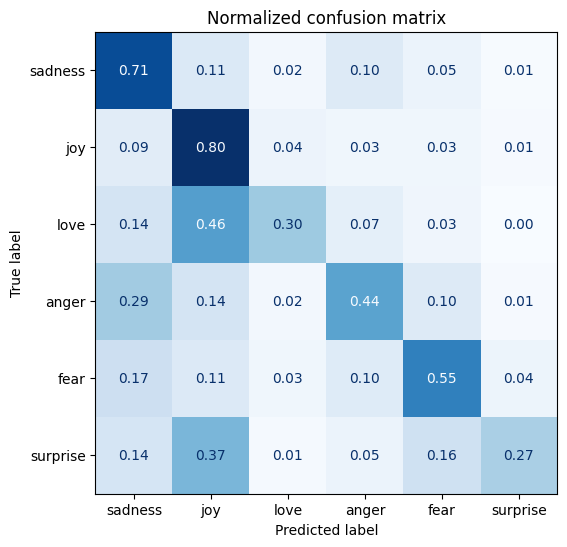

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()
labels = emotions["train"].features["label"].names
y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

Fine-Tuning Transformers

In [44]:
import torch_xla.core.xla_model as xm
device = xm.xla_device()
device

/tmp/ipykernel_1158/3361680353.py:2: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


device(type='xla', index=0)

In [45]:
from transformers import AutoModelForSequenceClassification
num_lables = 6
model = (AutoModelForSequenceClassification.from_pretrained(model_ckpt,num_labels=num_lables).to(device))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
from sklearn.metrics import accuracy_score,f1_score

def compute_metrics(pred):
  lables = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(lables,preds,average="weighted")
  acc = accuracy_score(lables,preds)
  return {"accuracy":acc,"f1":f1}


In [53]:
from transformers import Trainer , TrainingArguments
batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned"
training_args = TrainingArguments(output_dir = model_name,
                                  num_train_epochs=2,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  logging_steps=logging_steps,
                                  push_to_hub=False,
                                  weight_decay=0.01,
                                  eval_strategy="epoch",
                                  disable_tqdm=False,
                                  save_strategy="epoch",
                                  learning_rate=2e-5,
                                  optim="adamw_torch"#Only for TPU
                                  )

In [54]:
trainer = Trainer(model=model,args=training_args,compute_metrics=compute_metrics,train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded['validation'],processing_class=tokenizer)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.864212,0.322431,0.903500,0.900485
2,0.258561,0.222259,0.925500,0.924717


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  self._pin_memory_device = (


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.5613864440917968, metrics={'train_runtime': 189.5564, 'train_samples_per_second': 168.815, 'train_steps_per_second': 2.638, 'total_flos': 720342861696000.0, 'train_loss': 0.5613864440917968, 'epoch': 2.0})

In [55]:
preds_output = trainer.predict(emotions_encoded["validation"])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  self._pin_memory_device = (


In [56]:
preds_output.metrics

{'test_loss': 0.2222587764263153,
 'test_accuracy': 0.9255,
 'test_f1': 0.9247167986343493,
 'test_runtime': 0.5898,
 'test_samples_per_second': 3472.638,
 'test_steps_per_second': 54.26}

In [57]:
y_preds = np.argmax(preds_output.predictions, axis=1)

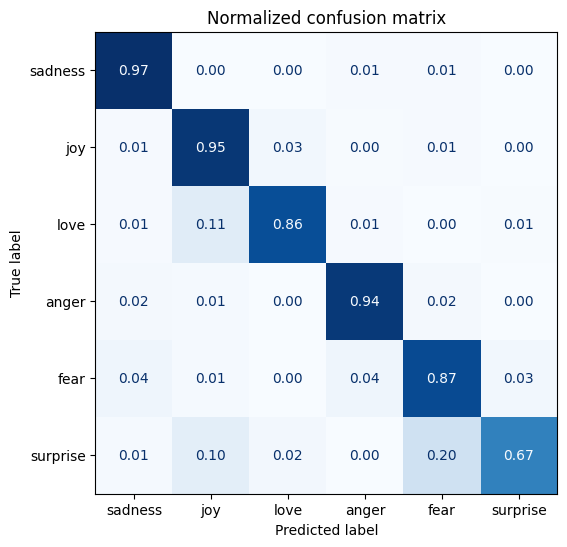

In [58]:
plot_confusion_matrix(y_preds, y_valid, labels)

In [59]:
preds_output = trainer.predict(emotions_encoded["test"])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  self._pin_memory_device = (


In [60]:
preds_output.metrics

{'test_loss': 0.22169378399848938,
 'test_accuracy': 0.917,
 'test_f1': 0.9156252269585204,
 'test_runtime': 12.3457,
 'test_samples_per_second': 165.887,
 'test_steps_per_second': 2.592}

In [61]:
y_preds = np.argmax(preds_output.predictions, axis=1)

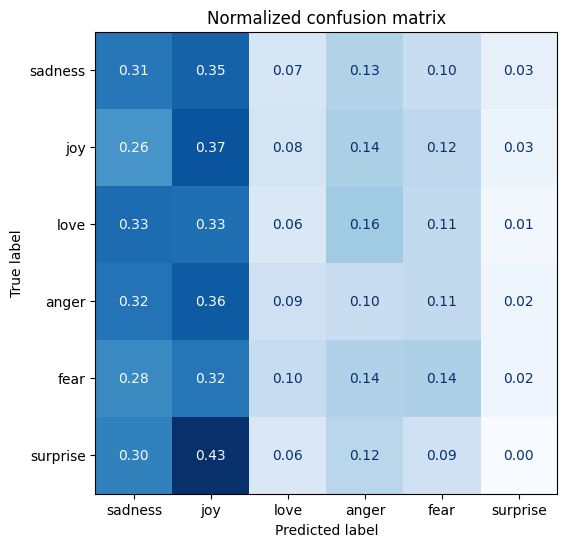

In [62]:
plot_confusion_matrix(y_preds, y_valid, labels)